Import libraries

In [1]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load dataset

In [2]:
#Load dataset
df = pd.read_csv('..\Datasets\Chocolate_Sales.csv')
df

,Order_ID,Product,Country,Channel,Salesperson,Order_Date,Discount_Pct,Price_per_Box,Marketing_Spend,Boxes_Shipped,Amount
0,ORD-069833,Truffle Gift Box,Australia,Retail,Arjun Mehta,2022-12-11,3.5,13.72,202.03,71,912.31
1,ORD-090726,85% Dark Bar,Australia,Retail,Arjun Mehta,2023-03-14,9.4,3.30,55.18,84,245.91
2,ORD-042159,70% Dark Bar,Japan,Retail,Hannah Müller,2023-12-21,4.9,18.21,60.65,35,583.7
3,ORD-197166,Hazelnut Milk Bar,Germany,Retail,Arjun Mehta,2023-12-18,15.0,2.66,52.00,92,211.27
4,ORD-112162,Almond Crunch Bar,Australia,Retail,Yuki Sato,2023-08-18,4.4,2.75,187.44,214,549.69
...,...,...,...,...,...,...,...,...,...,...,...
199995,ORD-053460,70% Dark Bar,Australia,Retail,Beatriz Souza,2022-05-27,10.6,3.39,186.19,125,418.56
199996,ORD-010743,Truffle Gift Box,India,Wholesale,Arjun Mehta,2022-09-06,17.3,3.07,42.28,148,366.47
199997,ORD-049690,Salted Caramel Bar,Japan,Online,Arjun Mehta,2022-06-16,18.3,2.74,100.19,149,329.79
199998,ORD-189637,85% Dark Bar,Japan,Wholesale,Rohan Patel,2022-10-14,9.3,14.30,29.96,24,304.51


Inspect Dataset

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Order_ID         200000 non-null  object 
 1   Product          200000 non-null  object 
 2   Country          200000 non-null  object 
 3   Channel          200000 non-null  object 
 4   Salesperson      200000 non-null  object 
 5   Order_Date       199563 non-null  object 
 6   Discount_Pct     199511 non-null  float64
 7   Price_per_Box    199543 non-null  float64
 8   Marketing_Spend  199539 non-null  float64
 9   Boxes_Shipped    200000 non-null  int64  
 10  Amount           200000 non-null  object 
dtypes: float64(3), int64(1), object(7)
memory usage: 16.8+ MB


In [4]:
df.describe()

,Discount_Pct,Price_per_Box,Marketing_Spend,Boxes_Shipped
count,199511.000000,199543.000000,199539.000000,200000.000000
mean,13.107457,5.911507,95.450141,139.584105
std,6.374477,4.954976,66.243760,118.665393
min,0.000000,2.040000,4.300000,-1642.000000
25%,8.300000,2.950000,52.270000,67.000000
50%,12.600000,3.280000,78.850000,113.000000
75%,17.500000,4.570000,118.710000,180.000000
max,38.300000,21.650000,798.222443,3811.000000


In [5]:
df.isnull().sum()

Order_ID             0
Product              0
Country              0
Channel              0
Salesperson          0
Order_Date         437
Discount_Pct       489
Price_per_Box      457
Marketing_Spend    461
Boxes_Shipped        0
Amount               0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

Convert Data Types

In [ ]:
# Convert date column to datetime
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='mixed', dayfirst=True, errors='coerce')
df.dtypes

Order_ID                   object
Product                    object
Country                    object
Channel                    object
Salesperson                object
Order_Date         datetime64[ns]
Discount_Pct              float64
Price_per_Box             float64
Marketing_Spend           float64
Boxes_Shipped               int64
Amount                     object
dtype: object

In [8]:
#Convert Amount to numeric
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')
df.dtypes

Order_ID                   object
Product                    object
Country                    object
Channel                    object
Salesperson                object
Order_Date         datetime64[ns]
Discount_Pct              float64
Price_per_Box             float64
Marketing_Spend           float64
Boxes_Shipped               int64
Amount                    float64
dtype: object

Handle Missing Values

In [9]:
# Inpute missing numeric values with median, categorical with mode
for col in ['Discount_Pct','Marketing_Spend', 'Price_per_Box','Amount']:
    df[col] = df[col].fillna(df[col].median())

df['Country'] = df['Country'].fillna(df['Country'].mode()[0])

df = df.dropna(subset=['Boxes_Shipped', 'Order_Date'])

df.isnull().sum()

Order_ID           0
Product            0
Country            0
Channel            0
Salesperson        0
Order_Date         0
Discount_Pct       0
Price_per_Box      0
Marketing_Spend    0
Boxes_Shipped      0
Amount             0
dtype: int64

Outlier Handling

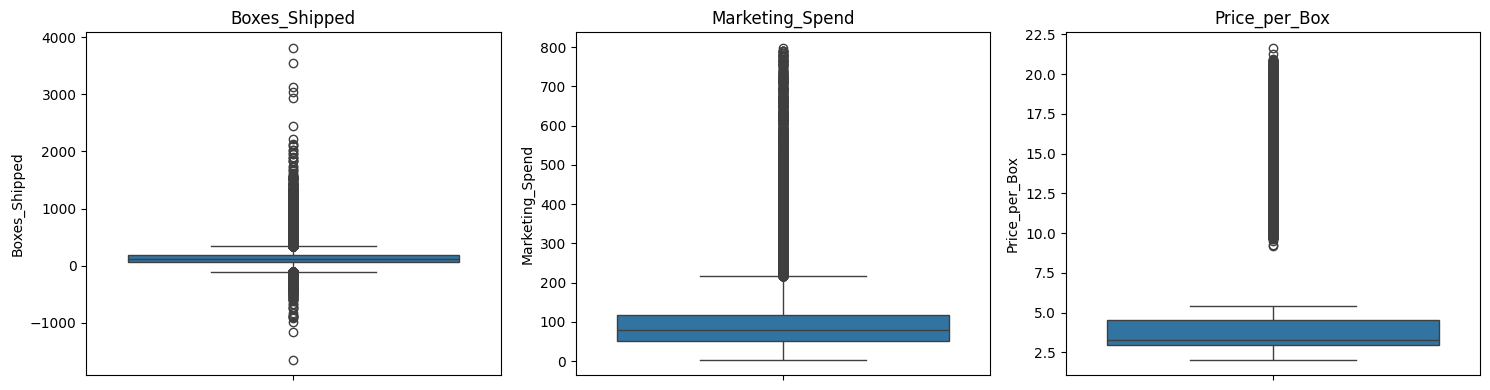

C:\Users\sho_taso\AppData\Local\Temp\ipykernel_9964\41109464.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].clip(lo, hi)
C:\Users\sho_taso\AppData\Local\Temp\ipykernel_9964\41109464.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].clip(lo, hi)
C:\Users\sho_taso\AppData\Local\Temp\ipykernel_9964\41109464.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See t

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(y=df['Boxes_Shipped'], ax=axes[0]); axes[0].set_title('Boxes_Shipped')
sns.boxplot(y=df['Marketing_Spend'], ax=axes[1]); axes[1].set_title('Marketing_Spend')
sns.boxplot(y=df['Price_per_Box'], ax=axes[2]); axes[2].set_title('Price_per_Box')
plt.tight_layout()
plt.show()

for col in ['Boxes_Shipped', 'Marketing_Spend', 'Price_per_Box']:
    lo, hi = df[col].quantile([0.01, 0.99])
    df[col] = df[col].clip(lo, hi)

Save Cleaned Dataset

In [11]:
df.to_csv('../Datasets/Clean_Chocolate_Sales.csv', index=False)

In [13]:
df["month"] = df["Order_Date"].dt.to_period("M").dt.to_timestamp()

C:\Users\sho_taso\AppData\Local\Temp\ipykernel_9964\405116112.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["month"] = df["Order_Date"].dt.to_period("M").dt.to_timestamp()


In [ ]:
monthly_sales = (
    df.groupby("month")["Amount"]
      .sum()
      .reset_index(name="revenue")
      .sort_values("month")
)

monthly_sales

        month     revenue
0  2022-01-01  4637766.12
1  2022-02-01  4007599.03
2  2022-03-01  3945061.08
3  2022-04-01  3777937.22
4  2022-05-01  3863712.32
5  2022-06-01  3582034.51
6  2022-07-01  3708488.53
7  2022-08-01  3943153.27
8  2022-09-01  3968065.09
9  2022-10-01  4240833.00
10 2022-11-01  4744312.76
11 2022-12-01  5441084.08
12 2023-01-01  5024630.42
13 2023-02-01  4073441.26
14 2023-03-01  4051247.24
15 2023-04-01  3951195.28
16 2023-05-01  4050942.62
17 2023-06-01  3736916.83
18 2023-07-01  3885587.26
19 2023-08-01  4140840.88
20 2023-09-01  4114981.27
21 2023-10-01  4532778.59
22 2023-11-01  5005479.18
23 2023-12-01  5624209.85


In [15]:
monthly_sales

,month,revenue
0,2022-01-01,4637766.12
1,2022-02-01,4007599.03
2,2022-03-01,3945061.08
3,2022-04-01,3777937.22
4,2022-05-01,3863712.32
5,2022-06-01,3582034.51
6,2022-07-01,3708488.53
7,2022-08-01,3943153.27
8,2022-09-01,3968065.09
9,2022-10-01,4240833.00


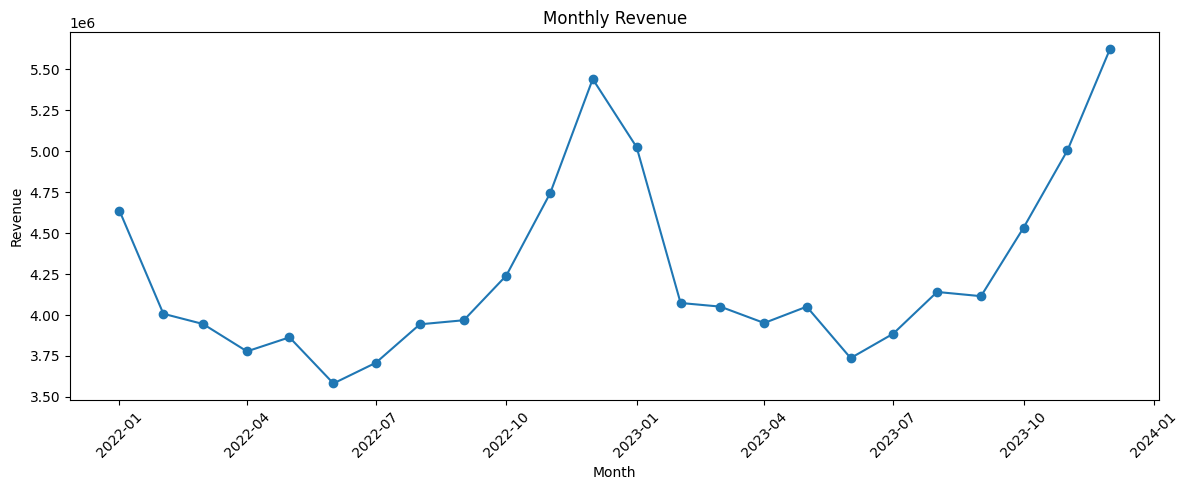

In [16]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales["month"],
    monthly_sales["revenue"],
    marker="o"
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()